In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import networkx as nx
import scipy.sparse as scipy_sparse

from qlinks.basis import Basis
from qlinks.encoded import BinaryEncodedBasis
from qlinks.caging import (
    CageSearchConfig,
    CageSearcher,
    classify_cage_state,
)
from qlinks.models import (
    SquareQLMModel,
    SquareQDMModel,
    TriangularQLMModel,
    TriangularQDMModel,
    HoneycombQLMModel,
    HoneycombQDMModel,
)
from qlinks.visualizer import (
    LinkVisualStyle,
    BasisGridVisualizer,
    HamiltonianGraphStyle,
    HamiltonianGraphVisualizer,
)

In [2]:
def basis_configs_from_build_result(build_result) -> np.ndarray:
    """Return explicit basis configurations with shape (n_states, n_variables)."""
    basis = build_result.basis

    if isinstance(basis, Basis):
        return basis.states

    if isinstance(basis, BinaryEncodedBasis):
        return basis.to_array_basis().states

    raise TypeError(
        "build_result.basis must be Basis or BinaryEncodedBasis, "
        f"got {type(basis)!r}."
    )


def diagonal_values(matrix) -> np.ndarray:
    """Return diagonal values of a dense or sparse matrix."""
    if scipy_sparse.issparse(matrix):
        values = matrix.diagonal()
    else:
        values = np.diag(matrix)

    return np.asarray(values, dtype=np.complex128)


def offdiagonal_nnz(matrix) -> int:
    """Return number of off-diagonal nonzero entries."""
    sparse_matrix = scipy_sparse.csr_array(matrix).copy()
    sparse_matrix.setdiag(0)
    sparse_matrix.eliminate_zeros()

    return int(sparse_matrix.nnz)


def finite_amplitude_indices(
    state_vector: np.ndarray,
    *,
    tolerance: float = 1e-12,
) -> np.ndarray:
    """Return basis indices with numerically nonzero amplitude."""
    return np.flatnonzero(np.abs(state_vector) > tolerance).astype(np.int64)


def basis_states_array(basis):
    """Extract the raw basis-state array."""
    if hasattr(basis, "states"):
        return np.asarray(basis.states)

    if hasattr(basis, "configs"):
        return np.asarray(basis.configs)

    raise AttributeError(
        "Expected basis to expose either `states` or `configs`."
    )

In [47]:
model = HoneycombQDMModel(
    lx=4,
    ly=4,
    boundary_condition="periodic",
    winding_x=-2,
    winding_y=0,
    # charge_magnitude=1,
    kinetic=1.0,
    potential=1.0,
)
print(model.allowed_sector_labels())

{'winding_x': (Fraction(-4, 1), Fraction(-2, 1), Fraction(0, 1), Fraction(2, 1), Fraction(4, 1)), 'winding_y': (Fraction(-4, 1), Fraction(-2, 1), Fraction(0, 1), Fraction(2, 1), Fraction(4, 1))}


In [48]:
build_result = model.build(
    basis_solver="dfs",
    builder="sparse",
    backend="scipy",
    sort_basis=True,
    on_missing="raise",
)

hamiltonian_matrix = build_result.hamiltonian
kinetic_matrix = build_result.kinetic
potential_matrix = build_result.potential
basis = build_result.basis

print("n_states =", basis.n_states)
print("H shape =", hamiltonian_matrix.shape)
print("H nnz =", hamiltonian_matrix.nnz)
print("K nnz =", kinetic_matrix.nnz)
print("K offdiag nnz =", offdiagonal_nnz(kinetic_matrix))
print("V nnz =", potential_matrix.nnz)
print("K is bipartite =", nx.is_bipartite(nx.from_scipy_sparse_array(kinetic_matrix, edge_attribute="weight")))

n_states = 124
H shape = (124, 124)
H nnz = 700
K nnz = 576
K offdiag nnz = 576
V nnz = 124
K is bipartite = True


In [49]:
config = CageSearchConfig(
    search_type="qlm",
    type1_kappas=(0,),
    # type2_kappas=(-2, 2),
    tolerance=1e-10,
    degenerate_basis_strategy="ipr",
    ipr_n_restarts=256,
    ipr_candidate_count=128,
    ipr_random_seed=1234,
)

searcher = CageSearcher.from_model_build_result(
    build_result,
    config=config,
)

result = searcher.run()
print(result.counts_by_signature)

{(0, 3): 1, (0, 4): 4, (0, 6): 1}


In [50]:
record = result[(0, 4), 0]
full_state = record.full_state

In [51]:
report = classify_cage_state(
    record.cage_state,
    kinetic_matrix=build_result.kinetic,
    basis_configs=basis_configs_from_build_result(build_result),
    hilbert_size=build_result.basis.n_states,
)

print(report)

Cage classification report
label: extended_candidate

Support
-------
support size: 8
Hilbert size: 124
support fraction: 0.0645161

Interference zeros
------------------
nontrivial zeros: 16
distinct local patterns: 12

Complement closure
------------------
complement targets: 0
unexplained complement targets: 0
fraction zeros with closed complement targets: 1

Operator diagnostics
--------------------
mean Q-sector weight: 0.75
max Q-sector weight: 0.75
mean reduced action norm: 3.886e-16
max reduced action norm: 8.882e-16
mean complement action norm: 0
max complement action norm: 0

Metadata
--------
boundary_residual: 3.493553692748378e-15
eigen_residual: 2.5121479338940403e-15
energy: (3.999999999999998+0j)
full_residual: 4.304219707205072e-15
support_size: 8


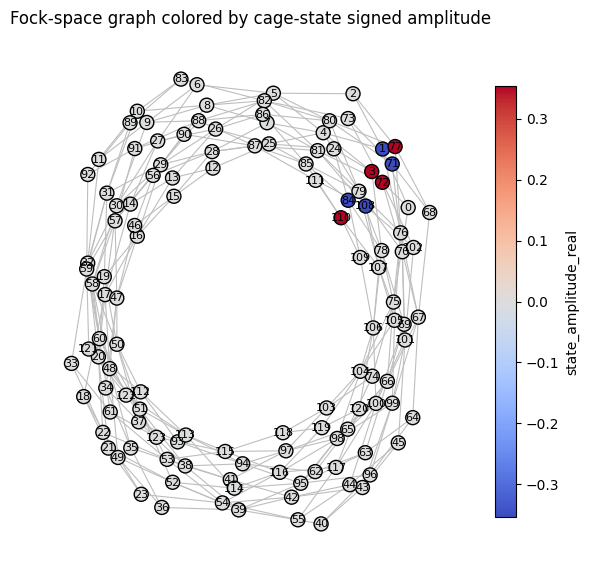

<Axes: title={'center': 'Fock-space graph colored by cage-state signed amplitude'}>

In [57]:
graph_visualizer = HamiltonianGraphVisualizer.from_sparse_matrix(
    kinetic_matrix,
    include_self_loops=False,
    style=HamiltonianGraphStyle(
        cmap="coolwarm",
        label_vertices=True,
        # vertex_size=10,
    ),
)

graph_visualizer.plot(
    backend="igraph",
    color_by="state_amplitude_real",
    state_vector=full_state,
    layout="fr",
    title=f"Fock-space graph colored by cage-state signed amplitude",
)

In [55]:
graph_visualizer.save_graph(
    f"../data/fock_graph.gexf",
    layout_backend="igraph",
    layout="kk",
    color_by="state_amplitude_real",
    state_vector=full_state,
)

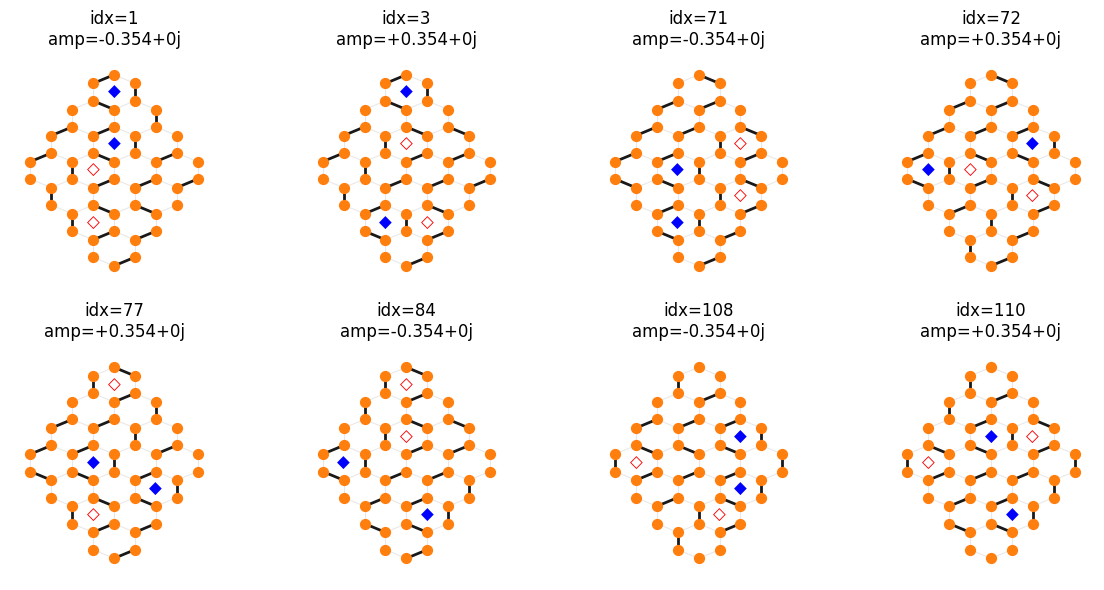

(<Figure size 1200x600 with 8 Axes>,
 array([[<Axes: title={'center': 'idx=1\namp=-0.354+0j'}>,
         <Axes: title={'center': 'idx=3\namp=+0.354+0j'}>,
         <Axes: title={'center': 'idx=71\namp=-0.354+0j'}>,
         <Axes: title={'center': 'idx=72\namp=+0.354+0j'}>],
        [<Axes: title={'center': 'idx=77\namp=+0.354+0j'}>,
         <Axes: title={'center': 'idx=84\namp=-0.354+0j'}>,
         <Axes: title={'center': 'idx=108\namp=-0.354+0j'}>,
         <Axes: title={'center': 'idx=110\namp=+0.354+0j'}>]], dtype=object))

In [54]:
grid_visualizer = BasisGridVisualizer(
    lattice=model.lattice,
    layout=model.layout,
    periodic_image_mode="positive_patch",
    collapse_duplicate_visual_links=True,
    site_label_style="sublattice_cell",
    coordinate_transform=np.array(
        [
            [1.0, 0.0],
            [0.0, 0.72],
        ],
        dtype=float,
    ),
    style=LinkVisualStyle(
        node_size=50.0,
        plaquette_symbol_fontsize=12,
        # plaquette_symbol_offset=(-0.01, 0.01),
    ),
)

amplitude_tolerance = 1e-10

nonzero_indices = finite_amplitude_indices(
    full_state,
    tolerance=amplitude_tolerance,
)

basis_state_array = basis_states_array(basis)
support_states = basis_state_array[nonzero_indices]

labels = [
    f"idx={int(basis_index)}\n"
    f"amp={full_state[int(basis_index)].real:+.3g}"
    f"{full_state[int(basis_index)].imag:+.3g}j"
    for basis_index in nonzero_indices
]

grid_visualizer.plot(
    support_states,
    labels=labels,
    ncols=4,
    mode="dimers",
    plaquette_symbols="resonance",
    show_config_label=False,
    # suptitle="Basis states with finite cage-state amplitude",
    single_plot_kwargs={
        "with_site_labels": False,
        "with_site_values": False,
        "with_link_values": False,
    },
)

In [ ]:
grid_visualizer = BasisGridVisualizer(
    lattice=model.lattice,
    layout=model.layout,
    periodic_image_mode="positive_patch",
    collapse_duplicate_visual_links=True,
    # site_label_style="sublattice_cell",
    # coordinate_transform=np.array(
    #     [
    #         [1.0, 0.0],
    #         [0.0, 0.72],
    #     ],
    #     dtype=float,
    # ),
    # style=LinkVisualStyle(
    #     node_size=50.0,
    #     # plaquette_symbol_offset=(-0.01, 0.01),
    # ),
)

grid_visualizer.plot(
    basis.states,
    ncols=4,
    mode="arrows",
    plaquette_symbols="square_qlm",
    show_config_label=False,
    suptitle="All basis configurations",
    single_plot_kwargs={
        "with_site_labels": False,
        "with_site_values": False,
        "with_link_values": False,
    },
)